# Prepare

In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import qutip as qt
from copy import deepcopy

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base
from fitting.fit_display_classes import GeneralFitting
from fitting.wigner import WignerAnalysis

from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

# Initialize database and config manager
db = get_database()
config_dir = 'D:/python/multimode_expts/configs'
config_manager = ConfigVersionManager(config_dir)

# Initialize job client (handle submitting and waiting for jobs)
client = JobClient()

# Check server health
health = client.health_check()
print(f"Server status: {health['status']}")
print(f"Pending jobs: {health['pending_jobs']}")

user = "guan"
print("Welcome", user)


station = MultimodeStation(
    user=user,
    experiment_name = "260410_qsim",
    
    hardware_config="CFG-HW-20260416-00005",
    storage_man_file="CFG-M1-20260416-00004",
    # floquet_file="CFG-FL-20260223-00017",
)

USE_QUEUE = True

mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soccfg)
# multiphoton_cfg_thisrun = AttrDict(deepcopy(mm_base_calib.multiphoton_cfg))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Server status: healthy
Pending jobs: 0
Welcome guan
[STATION] Using hardware_config version: CFG-HW-20260416-00005
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using man1_storage_swap version: CFG-M1-20260416-00004
[STATION] Using main floquet_storage_swap version: CFG-FL-20260223-00023
Data, plots, logs will be stored in: D:\experiments\260410_qsim
Hardware configs will be read from D:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260416-00005.yml
dict_keys(['Pyro.NameServer', 'Qick101'])
QICK running on ZCU216, software version 0.2.291

Firmware configuration (built Tue Oct 15 12:06:51 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=6389.760 MHz, fabric=399.360 MHz, 32-bit DDS, range=6389.760 MHz
		DAC tile 2, blk 0 is 0

# Setting up the Wigner tomography

## Single shot

In [2]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
singleshot_defaults = AttrDict(dict(    
    reps=5000,
    relax_delay=500,
    check_f=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    qubit=0,
    pulse_manipulate=False,
    # cavity_freq=4984.373226159381,
    # cavity_gain=400,
    # cavity_length=2,
    prepulse=False,
    pre_sweep_pulse=None,
    gate_based=True,
    qubits=[0],
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def singleshot_postproc(station, expt):
    expt.analyze(plot=False, station=station, subdir=station.autocalib_path)
    fids = expt.data['fids']
    confusion_matrix = expt.data['confusion_matrix']
    thresholds_new = expt.data['thresholds']
    angle = expt.data['angle']
    print(fids)

    hardware_cfg = station.hardware_cfg
    hardware_cfg.device.readout.phase = [hardware_cfg.device.readout.phase[0] + angle]
    hardware_cfg.device.readout.threshold = thresholds_new
    hardware_cfg.device.readout.threshold_list = [thresholds_new]
    hardware_cfg.device.readout.Ie = [np.median(expt.data['Ie_rot'])]
    hardware_cfg.device.readout.Ig = [np.median(expt.data['Ig_rot'])]
    if expt.cfg.expt.active_reset:
        hardware_cfg.device.readout.confusion_matrix_with_active_reset = confusion_matrix
    else:
        hardware_cfg.device.readout.confusion_matrix_without_reset = confusion_matrix
    print('Updated readout!')

Job submitted: JOB-20260421-00312 (queue position: 1)

[0.1s] Job JOB-20260421-00312: pending

[14.2s] Job JOB-20260421-00312: running
[WORKER] Loading HistogramExperiment from experiments.single_qubit.single_shot
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260421-00312_HistogramExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 66%|████████████████████████▏            | 3276/5000 [00:06<00:03, 499.02it/s]
[39.1s] Job JOB-20260421-00312: completed
100%|█████████████████████████████████████| 5000/5000 [00:10<00:00, 499.36it/s]
Unrotated:
Ig -77.64594594594595 +/- 29.799508433769027 	 Qg -59.90810810810811 +/- 26.510821885185663 	 Amp g 98.07076189636507
Ie 24.413513513513514 +/- 30.963133691524625 	 Qe -60.93378378378378 +/- 26.88885250940814 	 Amp e 65.6425597328701
Rotated:
Ig -77.00807203668066 +/- 29.796981461815353 	 Qg -60.70826704311344 +/- 26.51

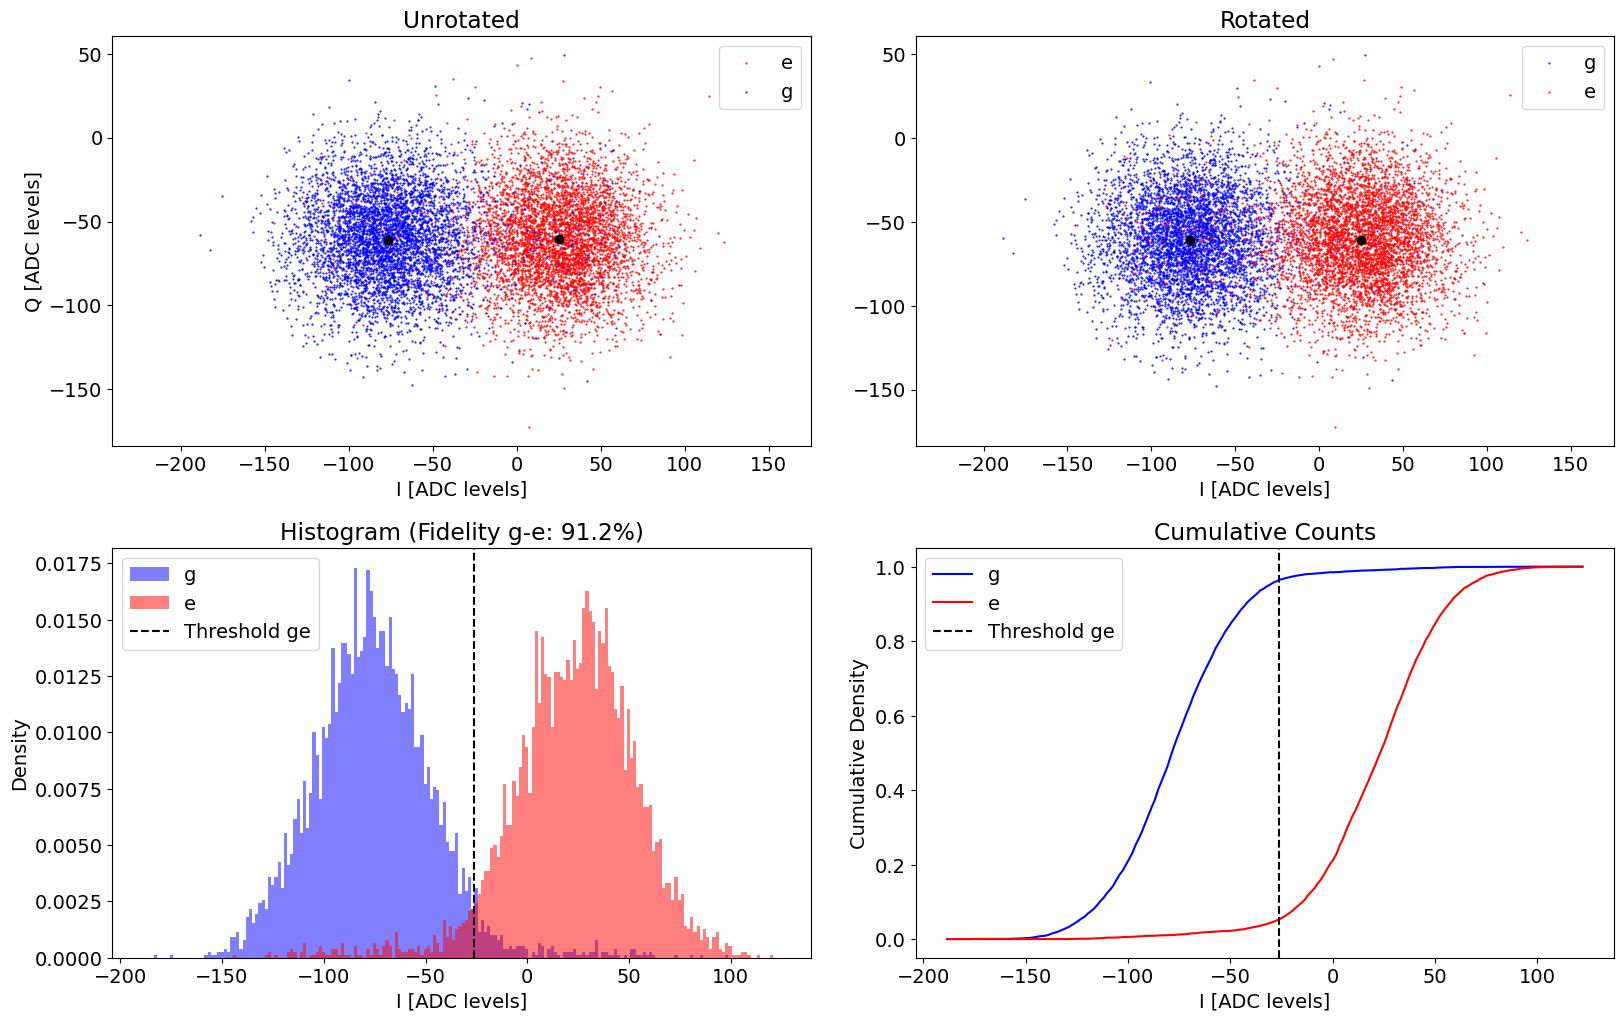

Plot saved to D:\experiments\260410_qsim\plots\2026-04-21_16-09-27_histogram.png
Plot reference appended to D:\experiments\260410_qsim\logs\2026-04-21.md
ge fidelity (%): 91.17823564712938
rotation angle (deg): 0.575790909993475
threshold ge: -26.0133947515001


In [5]:
# Execute
# =================================
ss_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.HistogramExperiment,
    default_expt_cfg = singleshot_defaults,
    postprocessor = singleshot_postproc,
    job_client=client,
)

ss = ss_runner.execute(
    go_kwargs=dict(analyze=False, display=False),
    check_f=False,
    active_reset=False, # on recalibration of readout, turn off active reset because it will be wrong for selecting when to apply the qubit pulse
    relax_delay=2000,
    # active_reset=True,
    # relax_delay=200,
    # coupler_current=0.5e-3,
)
ss.display(station)

In [18]:
station.snapshot_hardware_config(update_main=False)
station.preview_config_update()

[CONFIG] Reusing existing hardware_config version CFG-HW-20260223-00021
Comparing configurations:
Parent config file: D:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260223-00005.yml
Key 'device.readout.phase' differs:
  Old value (config1): [-50.54837091737717]
  New value (config2): [-92.9654337171046]
Key 'device.readout.threshold' differs:
  Old value (config1): [-68.19294323826705]
  New value (config2): [-63.08392856127193]
Key 'device.readout.threshold_list' differs:
  Old value (config1): [[-68.19294323826705]]
  New value (config2): [[-63.08392856127193]]
Key 'device.readout.confusion_matrix_without_reset' differs:
  Old value (config1): [0.9873999999999995, 0.0126000000000005, 0.03500700140028006, 0.96499299859972]
  New value (config2): [0.9852000000000005, 0.01479999999999948, 0.030600000000000016, 0.9694]
Key 'device.readout.Ie' differs:
  Old value (config1): [172.8737066862862]
  New value (config2): [175.20336065138625]
Key 'device.readout.Ig' differ

In [44]:
station.update_all_station_snapshots()

[CONFIG] Created new hardware_config version CFG-HW-20260302-00006
[CONFIG] Reusing existing multiphoton_config version CFG-MP-20260121-00001
[CONFIG] Reusing existing man1_storage_swap version CFG-M1-20260223-00007
[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260223-00017
Config snapshots for current station:
  hardware_config: CFG-HW-20260302-00006
  multiphoton_config: CFG-MP-20260121-00001
  man1_storage_swap: CFG-M1-20260223-00007
  floquet_storage_swap: CFG-FL-20260223-00017


{'hardware_config': 'CFG-HW-20260302-00006',
 'multiphoton_config': 'CFG-MP-20260121-00001',
 'man1_storage_swap': 'CFG-M1-20260223-00007',
 'floquet_storage_swap': 'CFG-FL-20260223-00017'}

## Photon Number Resolved  Spectroscopy

This is used to check that the fock states are well prepared before we do the tomography

In [4]:
photon_number_spectro_defaults = AttrDict(dict(
    start=3560, 
    step=0.1,
    expts=200,
    reps=2000,
    rounds=1,
    length=1,
    gain=400,
    sigma=0.1,
    qubits=[0],
    qubit=0,
    prepulse=False,
    pre_sweep_pulse=[],
    gate_based=False,
    relax_delay=250,
))

photon_number_spectro_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.pulse_probe_spectroscopy.PulseProbeSpectroscopyExperiment,
    default_expt_cfg=photon_number_spectro_defaults,
    job_client=client,
    use_queue=USE_QUEUE,
    # use_queue=False,
)

In [5]:
pre_sweep_pulse = mm_base_calib.prep_man_photon(man_no=1, photon_no=1)
pre_sweep_pulse = mm_base_calib.get_prepulse_creator(pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
print(f"pre_sweep_pulse: {pre_sweep_pulse}")

pre_sweep_pulse: [[3563.149430155541, 3419.1760186165175, 1998.7491605509501], [9318, 8275, 8000], [0, 0, 0.5760814409699041], [0, 0, 0], [2, 2, 0], ['gauss', 'gauss', 'flat_top'], [0.035, 0.035, 0.005]]


In [6]:
span = 5
expt = 100
step = span / expt
start = station.hardware_cfg.device.qubit.f_ge[0] - span*0.5
length = 15
gain=30

# if tomo_expts_to_run['photon_number_spectro']:
photon_number_spectro = photon_number_spectro_runner.execute(
    go_kwargs=dict(analyze=True, display=True, save=True),
    pre_sweep_pulse=pre_sweep_pulse,
    prepulse=True,
    gate_based=False,
    start=start,
    length=length,
    sigma=1.,
    gain=gain,
    step=step,
    expts=expt,
    relax_delay=500,
    coupler_current=0.0,
)

Job submitted: JOB-20260210-00411 (queue position: 1)

[0.1s] Job JOB-20260210-00411: pending

[2.1s] Job JOB-20260210-00411: running
[WORKER] Loading PulseProbeSpectroscopyExperiment from experiments.single_qubit.pulse_probe_spectroscopy
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260210-00411_PulseProbeSpectroscopyExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.0mA according to expt.cfg...
[WORKER] Done setting coupler current
 97%|███████████████████████████████▏| 194922/200000 [01:41<00:02, 1914.15it/s]
[135.3s] Job JOB-20260210-00411: completed
100%|████████████████████████████████| 200000/200000 [01:44<00:00, 1913.84it/s]
Saving D:\experiments\260128_qsim\data\JOB-20260210-00411_PulseProbeSpectroscopyExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260128_qsim\expt_objs\JOB-20260210-00411_expt.pkl

Job completed! Data: D:\experiments\260128_qsim\data\JOB-20260210-00411_PulseProbeSpectroscopyExperiment.h5


Found peak in amps at [MHz] 3562.449028539161, HWHM 0.4849999999999909
Found peak in I at [MHz] 3562.688140380496, HWHM -0.01068845671761481
Found peak in Q at [MHz] 3562.003202708876, HWHM -197.27667374189008


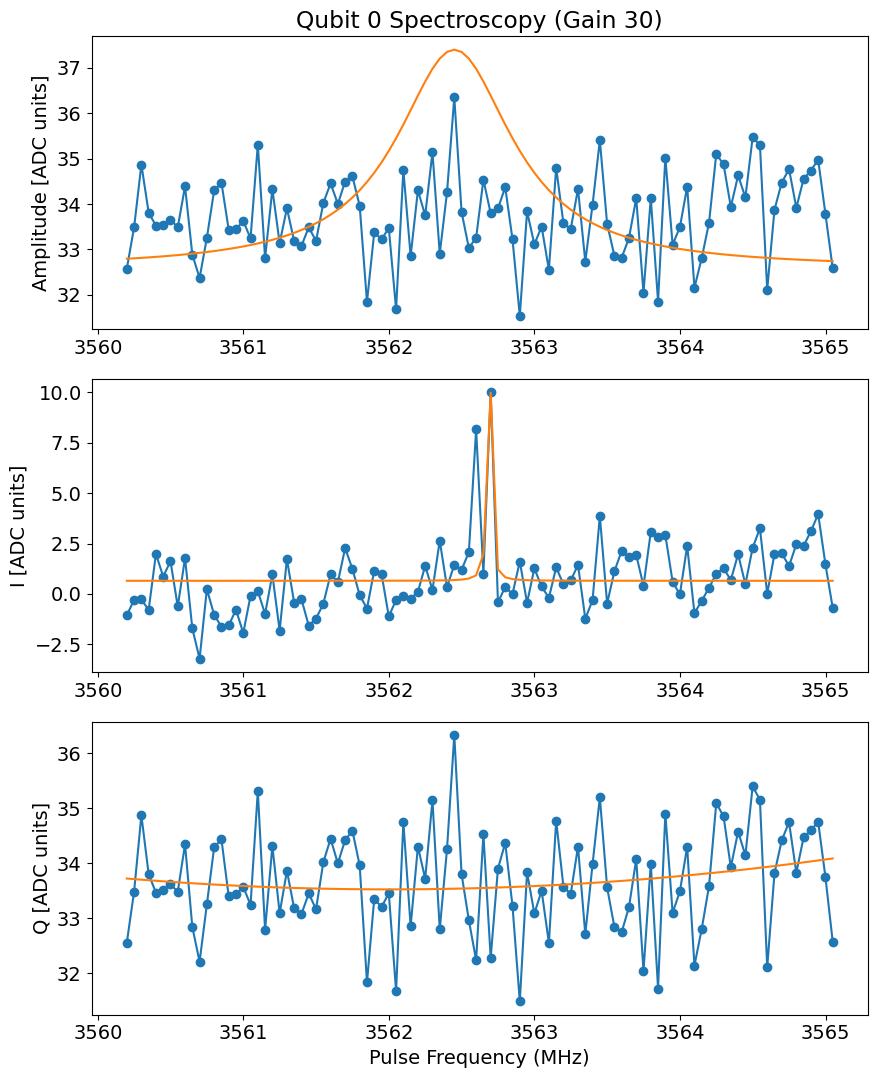

In [7]:
# if tomo_expts_to_run['photon_number_spectro']:
if USE_QUEUE:
    photon_number_spectro.display()

## Spectroscopy for f0g1

In [21]:
f0g1spec_defaults = AttrDict(dict(
    start=None,  # Will be computed in preprocessor from ds_storage
    step=0.2,
    expts=200,
    reps=100,
    rounds=1,
    length=1,
    gain=3000,
    pulse_type='gaussian',
    qubit_f=True,
    qubits=[0],
    prepulse=False,
    relax_delay=200,
))

def f0g1spec_preproc(station, default_expt_cfg, man_mode_no=1, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.man_mode_no = man_mode_no  # Store for postprocessor
    expt_cfg.update(kwargs)
    
    # Compute start frequency from dataset if not provided
    if expt_cfg.start is None:
        expt_cfg.start = station.ds_storage.get_freq('M' + str(man_mode_no)) - 20
    
    return expt_cfg

def f0g1spec_postproc(station, expt):
    man_mode_no = expt.cfg.expt.man_mode_no
    station.ds_storage.update_freq('M' + str(man_mode_no), expt.data['fit_avgi'][2])
    station.hardware_cfg.device.multiphoton['pi']['fn-gn+1']['frequency'][0] = expt.data['fit_avgi'][2]
    print(f"Updated man f0g1 freq to: {station.ds_storage.get_freq('M' + str(man_mode_no))}")
    station.snapshot_hardware_config(update_main=False)
    station.snapshot_man1_storage_swap(update_main=False)

Job submitted: JOB-20260210-00419 (queue position: 1)

[0.1s] Job JOB-20260210-00419: pending

[2.3s] Job JOB-20260210-00419: running
[WORKER] Loading PulseProbeF0g1SpectroscopyExperiment from experiments.single_qubit.pulse_probe_f0g1_spectroscopy
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260210-00419_PulseProbeF0g1SpectroscopyExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.0mA according to expt.cfg...
[WORKER] Done setting coupler current
 90%|███████████████████████████████▌   | 18018/20000 [00:45<00:04, 399.41it/s]
[56.8s] Job JOB-20260210-00419: completed
100%|███████████████████████████████████| 20000/20000 [00:50<00:00, 399.42it/s]
Saving D:\experiments\260128_qsim\data\JOB-20260210-00419_PulseProbeF0g1SpectroscopyExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260128_qsim\expt_objs\JOB-20260210-00419_expt.pkl

Job completed! Data: D:\experiments\260128_qsim\data\JOB-20260210-00419_PulseProbeF0g1Spectros

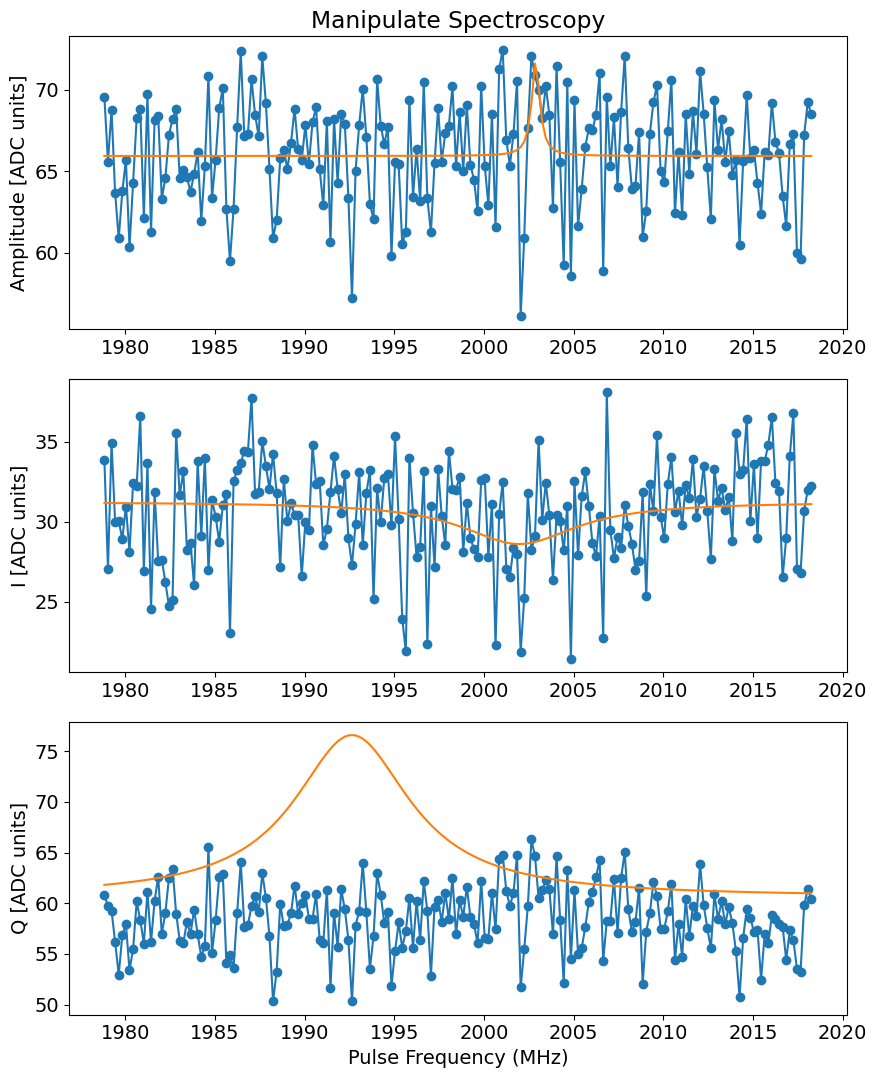

In [ ]:
# Execute
# =================================
f0g1spec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.PulseProbeF0g1SpectroscopyExperiment,
    default_expt_cfg=f0g1spec_defaults,
    preprocessor=f0g1spec_preproc,
    postprocessor=f0g1spec_postproc,
    job_client=client,
)

man_spec = f0g1spec_runner.execute(
    man_mode_no=1,
    start=1970,
    go_kwargs=dict(progress=True),
    relax_delay=250,
    # coupler_current=0.0,
)
man_spec.display()

## Parity Delay

In [6]:
parity_delay_defaults = AttrDict(dict(
    start=0.01,
    step=0.05,
    expts=50,
    reps=250,
    rounds=1,
    qubits=[0],
    parity_fast=False,
    normalize=False,
    active_reset=False,
    man_reset=True,
    gate_based=False,
    storage_reset=True,
    man_mode_no=1,
    relax_delay=2500, 
    param_to_calib='length', # length or ac_stark_shift 
    shift_sign=1, # 1 or -1 for ac stark shift direction
    ))


def parity_delay_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    if 'param_to_calib' in expt_cfg and expt_cfg.param_to_calib =='ac_stark_shift':
        expt_cfg.prepulse = False
        expt_cfg.pre_sweep_pulse = []
    elif 'param_to_calib' in expt_cfg and expt_cfg.param_to_calib =='length':
        expt_cfg.prepulse = True
        pre_sweep_pulse = mm_base_calib.prep_man_photon(man_no=expt_cfg.man_mode_no, photon_no=1)
        pre_sweep_pulse = mm_base_calib.get_prepulse_creator(pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.pre_sweep_pulse = pre_sweep_pulse
    return expt_cfg

def parity_delay_postproc(station, expt):
    from fitting.fit_display_classes import LengthRabiFitting
    # Analyze the data
    length_rabi_analysis = LengthRabiFitting(expt.data, config = expt.cfg)
    length_rabi_analysis.analyze() #fitparams = [100, 0.1, 0, None, None, None])
    length_rabi_analysis.display(title_str='Length Rabi General F0g1')
    expt_cfg = expt.cfg.expt
    man_mode_no = expt_cfg.man_mode_no
    shift_sign = expt_cfg.shift_sign


    if expt_cfg.param_to_calib == 'length':
        delay = length_rabi_analysis.results['pi_length']
        print(f'Fitted revival time: {delay} us')
        old_delay = station.hardware_cfg.device.manipulate.revival_time[man_mode_no - 1]
        station.hardware_cfg.device.manipulate.revival_time[man_mode_no - 1] = delay
        print(f'Updated revival time for mode {man_mode_no}: {old_delay} -> {station.hardware_cfg.device.manipulate.revival_time[man_mode_no - 1]}')

    elif expt_cfg.param_to_calib == 'ac_stark_shift': 
        freq = length_rabi_analysis.data['fit_avgi'][1]
        print(f'Fitted ac Stark shift: {freq} MHz')
        old_freq = station.hardware_cfg.device.manipulate.revival_stark_shift[man_mode_no - 1]
        station.hardware_cfg.device.manipulate.revival_stark_shift[man_mode_no - 1] += shift_sign * freq
        print(f'Updated ac Stark shift for mode {man_mode_no}: {old_freq} -> {station.hardware_cfg.device.manipulate.revival_stark_shift[man_mode_no - 1]}')


### Calibrate first the AC stark shift

Manipulate in 0, qubit should not rotate

this is calibrating the virtual Z to correct from rotating frame to bare frame

Job submitted: JOB-20260210-00418 (queue position: 1)

[0.2s] Job JOB-20260210-00418: pending

[2.2s] Job JOB-20260210-00418: running
[WORKER] Loading ParityDelayExperiment from experiments.single_qubit.parity_delay
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260210-00418_ParityDelayExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.0mA according to expt.cfg...
[WORKER] Done setting coupler current
 95%|██████████████████████████████████████▉  | 95/100 [00:33<00:01,  2.81it/s]theta_2: 339.13290570433855

[42.6s] Job JOB-20260210-00418: completed
100%|████████████████████████████████████████| 100/100 [00:35<00:00,  2.80it/s]
Saving D:\experiments\260128_qsim\data\JOB-20260210-00418_ParityDelayExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260128_qsim\expt_objs\JOB-20260210-00418_expt.pkl

Job completed! Data: D:\experiments\260128_qsim\data\JOB-20260210-00418_ParityDelayExperiment.h5
Attempted to init fitparam 4 to

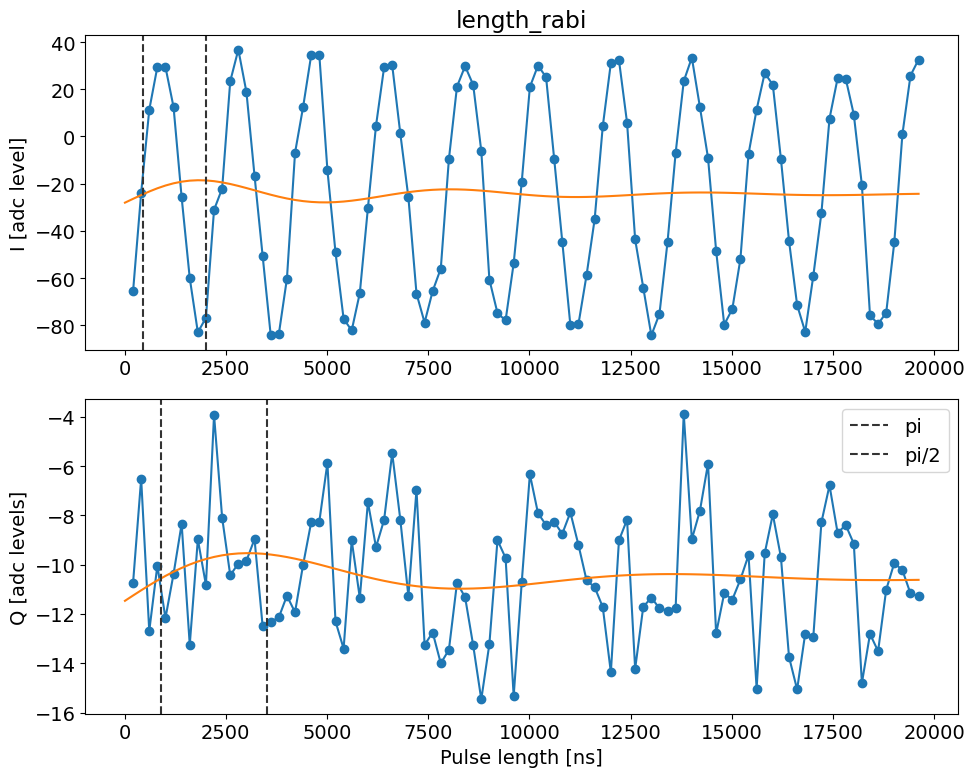

Fitted ac Stark shift: 0.16127549405936836 MHz
Updated ac Stark shift for mode 1: 0.33887616250282576 -> 0.5001516565621942


In [19]:
parity_delay_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityDelayExperiment,
    default_expt_cfg=parity_delay_defaults,
    postprocessor=parity_delay_postproc,
    preprocessor=parity_delay_preproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

parity_delay_ac_stark = parity_delay_runner.execute(
    param_to_calib='ac_stark_shift', 
    go_kwargs=dict(analyze=False, display=False),
    step=0.2,
    expts=100,
    reps=100,
    shift_sign=+1,
    coupler_current=0.0,
)

Confirming the correction is in the right direction

In [10]:
parity_delay_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityDelayExperiment,
    default_expt_cfg=parity_delay_defaults,
    preprocessor=parity_delay_preproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

parity_delay_ac_stark = parity_delay_runner.execute(
    param_to_calib='ac_stark_shift', 
    go_kwargs=dict(analyze=False, display=False),
    step=0.2,
    expts=100,
    reps=100,
    coupler_current=0.0,
)

Job submitted: JOB-20260210-00413 (queue position: 1)

[0.1s] Job JOB-20260210-00413: pending

[2.3s] Job JOB-20260210-00413: running
[WORKER] Loading ParityDelayExperiment from experiments.single_qubit.parity_delay
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260210-00413_ParityDelayExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.0mA according to expt.cfg...
[WORKER] Done setting coupler current
100%|████████████████████████████████████████| 100/100 [00:35<00:00,  2.80it/s]
Saving D:\experiments\260128_qsim\data\JOB-20260210-00413_ParityDelayExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260128_qsim\expt_objs\JOB-20260210-00413_expt.pkl

[42.9s] Job JOB-20260210-00413: completed

Job completed! Data: D:\experiments\260128_qsim\data\JOB-20260210-00413_ParityDelayExperiment.h5


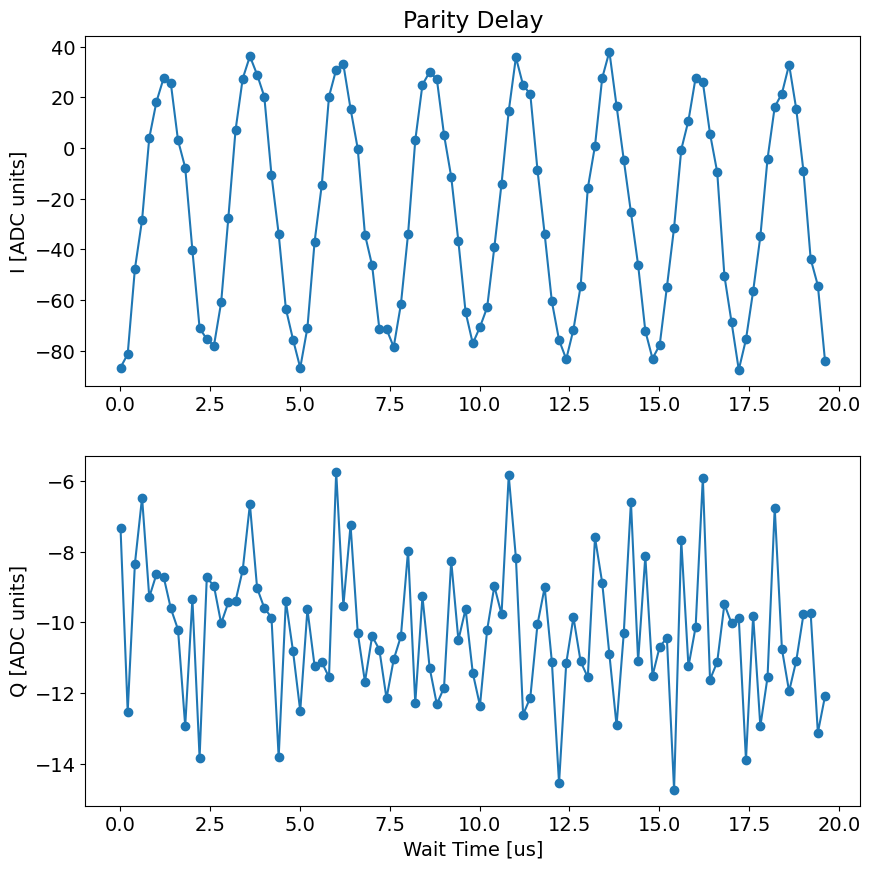

In [13]:
parity_delay_ac_stark.display(fit=False)

### Now parity length after the AC stark shift is calibrated

Job submitted: JOB-20260421-00315 (queue position: 1)

[0.1s] Job JOB-20260421-00315: pending

[35.0s] Job JOB-20260421-00315: running
[WORKER] Loading ParityDelayExperiment from experiments.single_qubit.parity_delay
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260421-00315_ParityDelayExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 96%|███████████████████████████████████████▎ | 96/100 [00:36<00:01,  2.58it/s]
[79.0s] Job JOB-20260421-00315: completed
100%|████████████████████████████████████████| 100/100 [00:37<00:00,  2.63it/s]
D:\python\multimode_expts\fitting\fitting.py:56: RuntimeWarning: overflow encountered in exp
  return y0 + yscale*np.exp(-(x-x0)/decay)
Saving D:\experiments\260410_qsim\data\JOB-20260421-00315_ParityDelayExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260410_qsim\expt_objs\JOB-20260421-00315_expt.pkl

Job comple

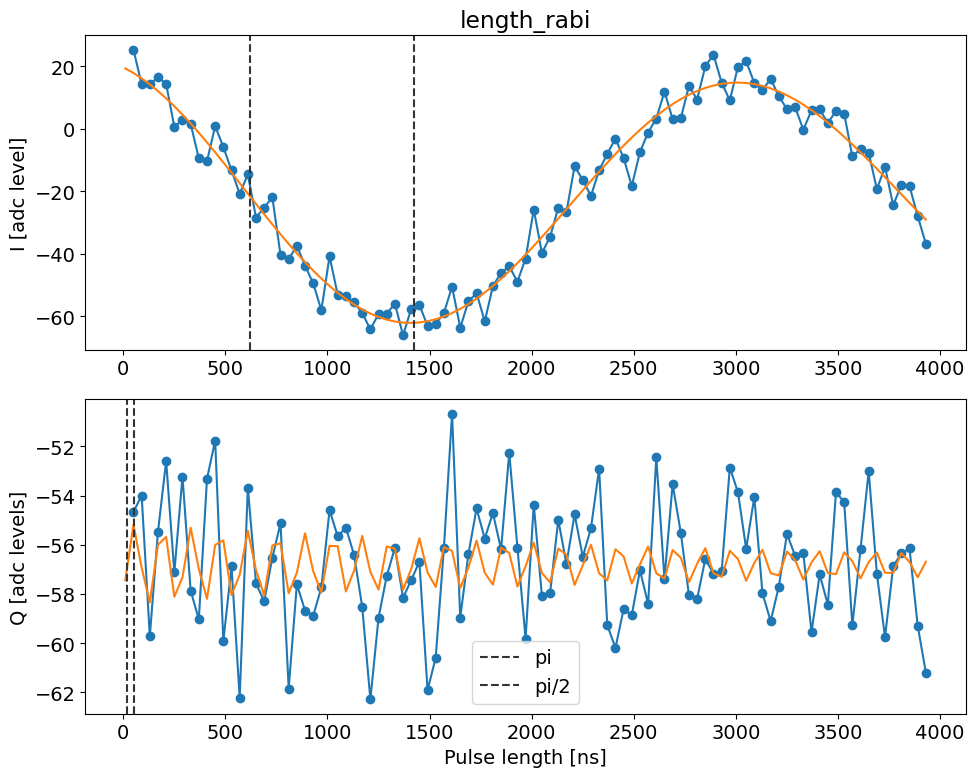

Fitted revival time: 1.4223752821434494 us
Updated revival time for mode 1: 1.776516662137038 -> 1.4223752821434494


In [7]:
parity_delay_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityDelayExperiment,
    default_expt_cfg=parity_delay_defaults,
    postprocessor=parity_delay_postproc,
    preprocessor=parity_delay_preproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

parity_delay_ac_stark = parity_delay_runner.execute(
    param_to_calib='length', 
    parity_fast=False,
    go_kwargs=dict(analyze=False, display=False),
    step=0.04,
    expts=100,
    reps=100,
    # coupler_current=0.0,
)

## Manipulate Parity Spectroscopy

In [17]:
station.hardware_cfg.device.manipulate

{'f_ge': [4979.617487284074, 5157.8527963217475],
 'displace_sigma': [0.05, 0.05],
 'revival_time': [1.2748561165170147, 1.7366205852286094],
 'revival_stark_shift': [0.005102040816355523, -2.6792227141937364],
 'gain_to_alpha': [0.0002664034142894277, 0.00020045],
 'freq_to_alpha': [0.495062203431879, 0.0],
 'alpha_scale': [1.0147418910101649, 1.0],
 'chi_ge': [0.2802173281623599],
 'chi_ef': [1.2311804927283654],
 'ramp_sigma': 0.005,
 'revival_time_fast': [1.7378951097046815, 1.7378951097046815]}

In [8]:
parity_freq_defaults = AttrDict(dict(
    start=4960,
    stop=5020,
    step=0.60,
    reps=200,
    rounds=1,
    qubits=[0],
    normalize=False,
    single_shot=False,
    singleshot_reps=10000,
    span=20,
    man_mode_no=1,
    displace=(True, 0.1, 1000),
    const_pulse=(False, 1),
    f0g1_cavity=0,
    prepulse=False,
    pre_sweep_pulse=None,
    relax_delay=2500,
))

def parity_freq_postproc(station, expt):
    from fitting.fit_display_classes import Spectroscopy
    spec = Spectroscopy(expt.data, config=expt.cfg)
    spec.analyze()
    spec.display(title='Parity Frequency Experiment')

    expt_cfg = expt.cfg.expt
    man_mode_no = expt_cfg.man_mode_no
    fitted_freq = spec.data['fit_avgi'][2]
    old_freq = station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1]
    station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1] = fitted_freq
    print(f'Updated manipulate f_ge for mode {man_mode_no} from {old_freq} to {fitted_freq}')


parity_freq_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityFreqExperiment,
    default_expt_cfg=parity_freq_defaults,
    postprocessor=parity_freq_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


Job submitted: JOB-20260421-00317 (queue position: 1)

[0.1s] Job JOB-20260421-00317: pending

[20.3s] Job JOB-20260421-00317: running
[WORKER] Loading ParityFreqExperiment from experiments.single_qubit.parity_freq
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260421-00317_ParityFreqExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
100%|████████████████████████████████████████| 100/100 [00:39<00:00,  2.54it/s]
Saving D:\experiments\260410_qsim\data\JOB-20260421-00317_ParityFreqExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260410_qsim\expt_objs\JOB-20260421-00317_expt.pkl

[66.5s] Job JOB-20260421-00317: completed

Job completed! Data: D:\experiments\260410_qsim\data\JOB-20260421-00317_ParityFreqExperiment.h5
Found peak in amps at [MHz] 4964.800000000003, HWHM 5.940000000003602
Found peak in I at [MHz] 4984.899411588462, HWHM 2.635746538108

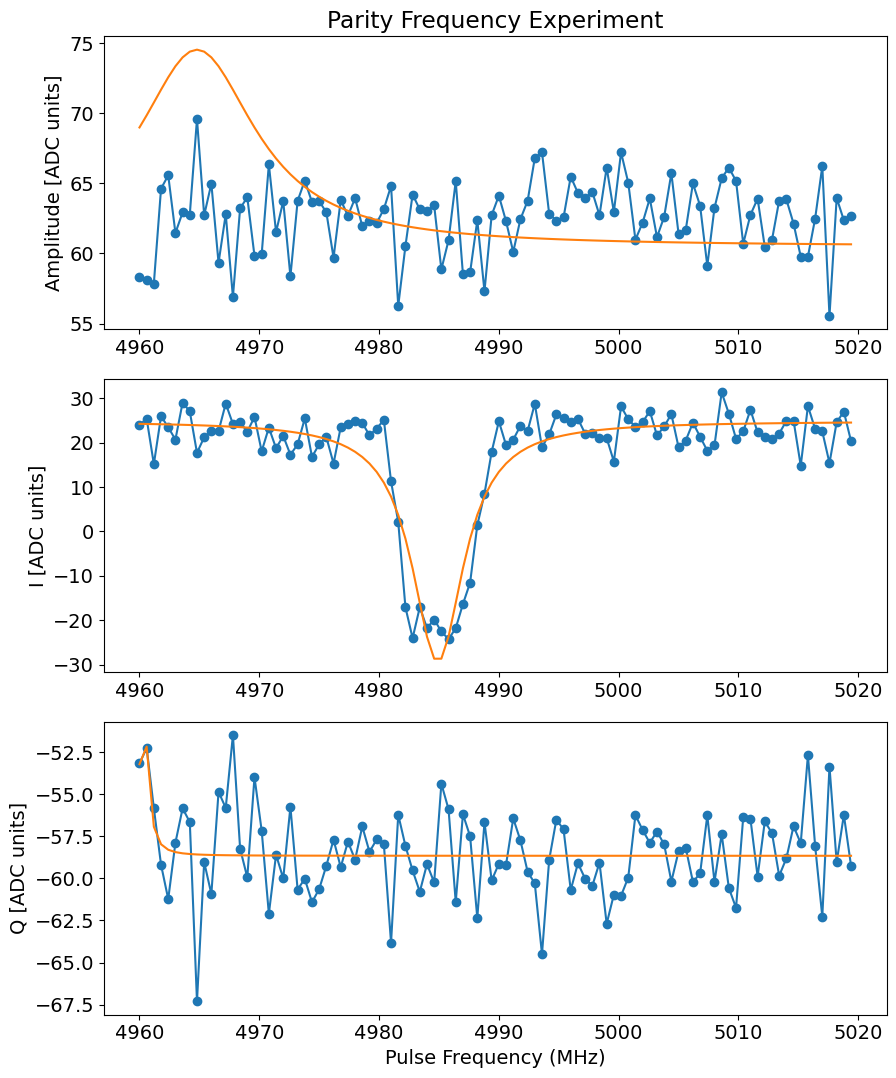

Updated manipulate f_ge for mode 1 from 5002.21890467344 to 4984.899411588462


In [9]:
parity_freq = parity_freq_runner.execute(
    go_kwargs=dict(analyze=False, display=False),
    reps=100,
    # coupler_current = 0e-3,
)

In [9]:
station.snapshot_hardware_config(update_main=False)

[CONFIG] Created new hardware_config version CFG-HW-20260211-00050


'CFG-HW-20260211-00050'

## Manipulate Ramsey (to finetune frequency)
- This will use displace pulse instead do qubit pi/2 to calibrate; we want fine calibration of manipulate frequency not some fast way of extracting T2 time or finding stark shift on f0g1 transition
- Make sure displacements are small $(\alpha \approx 0.2)$
- Somehow i don't get full contrast, like the lowst i,q value dont correspond to g 




In [10]:
cavity_ramsey_defaults = AttrDict(dict(
    start=0.01,           # start delay
    step=0.05,            # step size
    expts=200,            # number of experiments
    ramsey_freq=3.7,      # Ramsey frequency
    reps=100,              # repetitions
    rounds=1,             # rounds
    qubits=[0],           # qubits
    checkEF=False,        # check EF
    f0g1_cavity=0,        # f0g1 cavity
    init_gf=False,        # initialize gf
    active_reset=False,   # active reset
    man_reset=True,       # manipulate reset
    storage_reset=True,   # storage reset
    user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
    parity_meas=True,     # parity measurement
    man_mode_no=1,
    storage_ramsey=[False, 2, True], # storage Ramsey
    man_ramsey=None,      # manipulate Ramsey
    coupler_ramsey=False, # coupler Ramsey
    custom_coupler_pulse=None, # custom coupler pulse
    echoes=[False, 0],    # echoes
    prepulse=False,       # prepulse
    postpulse=False,      # postpulse
    gate_based=False,     # gate based
    pre_sweep_pulse=None, # pre sweep pulse
    post_sweep_pulse=None,# post sweep pulse
    prep_e_first = True,
    relax_delay=2500      # relax delay
))

def cavity_ramsey_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    expt_cfg.man_idx = expt_cfg.man_mode_no - 1

    if expt_cfg.user_defined_pulse is None:
        expt_cfg.user_defined_pulse = [True, station.hardware_cfg.device.manipulate.f_ge[expt_cfg.man_mode_no-1], 10, station.hardware_cfg.device.manipulate.displace_sigma[expt_cfg.man_mode_no-1], 0, 4]

    if expt_cfg.man_ramsey is None:
        expt_cfg.man_ramsey = [False, expt_cfg.man_mode_no -1]
    if expt_cfg.custom_coupler_pulse is None:
        expt_cfg.custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
    if expt_cfg.pre_sweep_pulse is None:
        expt_cfg.pre_sweep_pulse = []
    if expt_cfg.post_sweep_pulse is None:
        expt_cfg.post_sweep_pulse = []
    # do we need to set the relax delay here?
    return expt_cfg

def cavity_ramsey_postproc(station, expt):

    from fitting.fit_display_classes import RamseyFitting
    ramsey_analysis = RamseyFitting(expt.data, config=expt.cfg)
    delta_f = min(ramsey_analysis.data['f_adjust_ramsey_avgi'])

    expt_cfg = expt.cfg.expt
    man_mode_no = expt_cfg.man_mode_no
    old_freq = station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1]
    station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1] = old_freq + delta_f
    print(f'Updated manipulate f_ge for mode {man_mode_no} from {old_freq} to {station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1]}')

cavity_ramsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.t2_cavity.CavityRamseyExperiment,
    default_expt_cfg=cavity_ramsey_defaults,
    preprocessor=cavity_ramsey_preproc,
    postprocessor=cavity_ramsey_postproc,
    job_client=client,
    # user=user,    
    use_queue=USE_QUEUE,
)

In [11]:
# station.hardware_cfg.device.manipulate.f_ge[0]=4979.614305651117

cavity_ramsey = cavity_ramsey_runner.execute(
    ramsey_freq=1,
    step = 0.1,
    expts = 100,
    reps = 200,
    prep_e_first = False,
    user_defined_pulse=[True, 
                        station.hardware_cfg.device.manipulate.f_ge[0], 
                        1500, 
                        station.hardware_cfg.device.manipulate.displace_sigma[0],
                        0, 
                        4],
    # coupler_current = 0e-3,
)

Job submitted: JOB-20260421-00320 (queue position: 2)

[0.1s] Job JOB-20260421-00320: pending

[124.7s] Job JOB-20260421-00320: running
[WORKER] Loading CavityRamseyExperiment from experiments.single_qubit.t2_cavity
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260421-00320_CavityRamseyExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
100
100%|███████████████████████████████████| 20000/20000 [00:50<00:00, 397.91it/s]
No echoes in the data

[200.8s] Job JOB-20260421-00320: completed
Saving D:\experiments\260410_qsim\data\JOB-20260421-00320_CavityRamseyExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260410_qsim\expt_objs\JOB-20260421-00320_expt.pkl

Job completed! Data: D:\experiments\260410_qsim\data\JOB-20260421-00320_CavityRamseyExperiment.h5
Updated manipulate f_ge for mode 1 from 4984.899411588462 to 4984.878808529872


Using user defined frequency: 4984.899411588462 MHz
Current pi pulse frequency: 4984.899411588462
Fit frequency from I [MHz]: 1.0206030585898067 +/- 0.0033369420845314824
Suggested new pi pulse frequency from fit I [MHz]:
 	4984.878808529872
 	4986.920014647051
T2 Ramsey from fit I [us]: 61.02712308749788
Fit frequency from Q [MHz]: 1.0615882782543944 +/- 0.014547184329661603
Suggested new pi pulse frequencies from fit Q [MHz]:
 	4984.837823310208
 	4986.960999866716
T2 Ramsey from fit Q [us]: 59349473.00516538


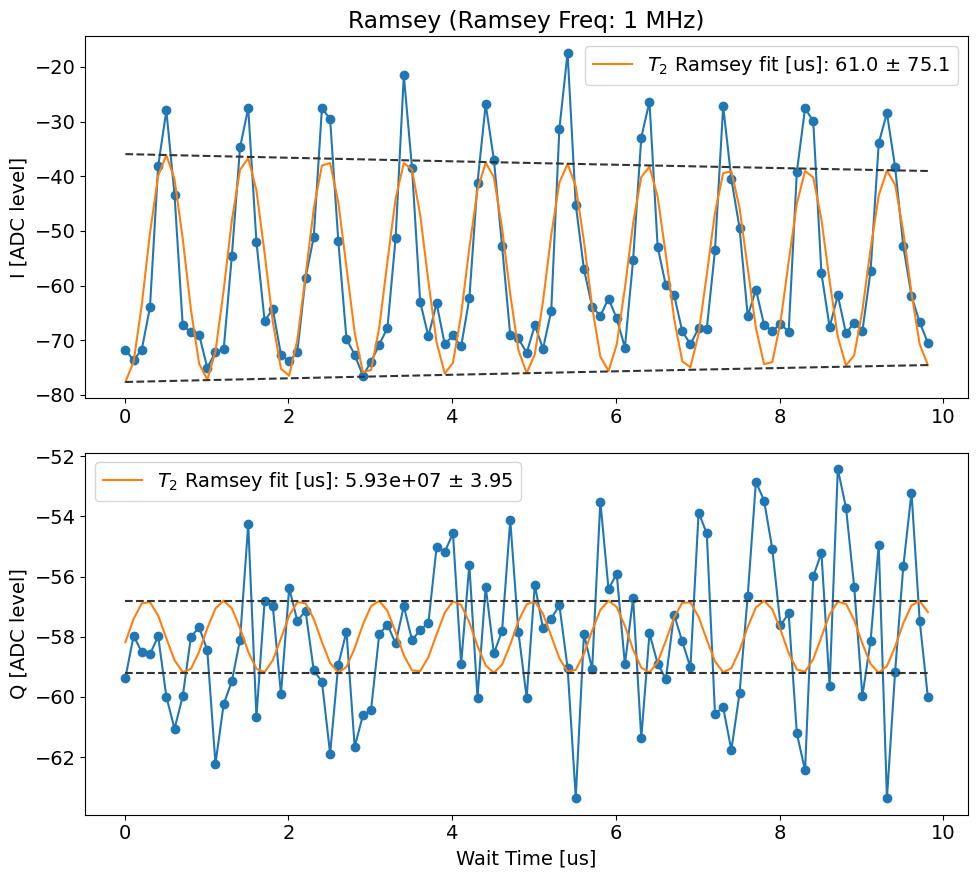

In [13]:
if USE_QUEUE:
    cavity_ramsey.display()

## Gain to alpha calibration

will do tomography on the vacuum state

$$
W_\alpha(\ket{0} \bra{0}) = \frac 2\pi e^{-2|\alpha|^2}
$$

In [14]:
do_parity_gain_defaults = AttrDict(dict(
    start=0,
    step=100,
    expts=40,
    reps=250,
    rounds=1,
    qubit=0,
    qubits=[0],
    normalize=False,
    single_shot=False,
    singleshot_reps=1000,
    singleshot_active_reset=False,
    singleshot_man_reset=True,
    singleshot_storage_reset=True,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    span=1000,
    prep_e=False,
    manipulate=1,
    displace=(True, 0.05), # [enable, sigma] (gaussian length is 4sigma)
    const_pulse=(False, 1), # [enable, length]
    f0g1_cavity=0,
    prepulse=False,
    pre_sweep_pulse=None,
    relax_delay=2500, 
    pulse_correction=False,
    parity_fast=True,
    scaling_amplitude=True,
    plot_IQ=True,
    man_mode_no=1,
))


def parity_gain_postproc(station, expt):
    expt_cfg = expt.cfg.expt
    scaling_amplitude = expt_cfg.scaling_amplitude
    man_mode_no = expt_cfg.man_mode_no
    if expt_cfg.plot_IQ:
        i_data = expt.data['idata']
        q_data = expt.data['qdata']
        fig, ax = plt.subplots(1,1, figsize=(6,6))
        ax.scatter(i_data, q_data, s=1, alpha=0.5)
        ax.set_xlabel('I')
        ax.set_ylabel('Q')
        ax.set_title('IQ Scatter Plot')
        plt.show()
    gain_to_alpha = expt.data['gain_to_alpha']
    old_gain_to_alpha = station.hardware_cfg.device.manipulate.gain_to_alpha[expt_cfg.man_mode_no - 1]
    print(f'Gain to alpha for mode {expt_cfg.man_mode_no} : {old_gain_to_alpha} -> {gain_to_alpha}')
    station.hardware_cfg.device.manipulate.gain_to_alpha[man_mode_no - 1] = gain_to_alpha
    if scaling_amplitude:
        scale = expt.data['scale']
        old_scale = station.hardware_cfg.device.manipulate.alpha_scale[man_mode_no - 1]
        station.hardware_cfg.device.manipulate.alpha_scale[man_mode_no - 1] = scale
        print(f'Scaling amplitude for mode {man_mode_no} : {old_scale} -> {scale}')


parity_gain_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.parity_gain.ParityGainExperiment,
    default_expt_cfg=do_parity_gain_defaults,
    postprocessor=parity_gain_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


Job submitted: JOB-20260421-00323 (queue position: 1)

[0.1s] Job JOB-20260421-00323: pending

[19.0s] Job JOB-20260421-00323: running
[WORKER] Loading ParityGainExperiment from experiments.single_qubit.parity_gain
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260421-00323_ParityGainExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
4984.878808529872
Updating gain register 150
100%|███████████████████████████████████| 12000/12000 [00:30<00:00, 399.32it/s]
4984.878808529872
Updating gain register 150
 96%|█████████████████████████████████▍ | 11466/12000 [00:28<00:01, 399.30it/s]
[84.5s] Job JOB-20260421-00323: completed
100%|███████████████████████████████████| 12000/12000 [00:30<00:00, 399.33it/s]
plot: False
Gain to Alpha Conversion Factor: 0.0007313895881004191
alpha = 1 requires gain of : 1367.26037159
Saving D:\experiments\260410_qsim\data\JOB-2026042

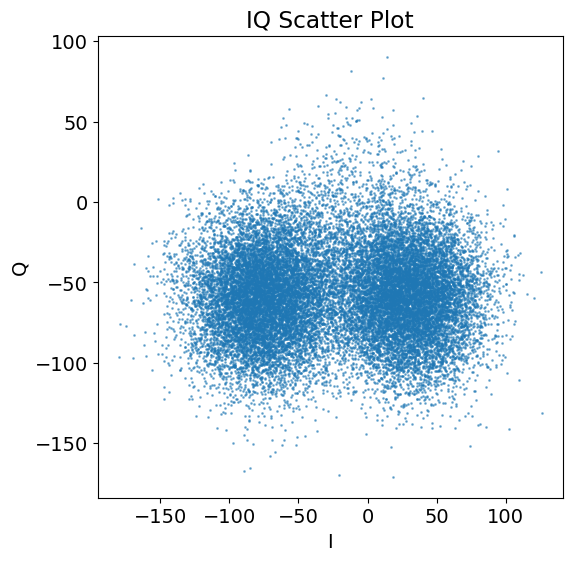

Gain to alpha for mode 1 : 0.00013274860618085058 -> 0.0007313895881004191
Scaling amplitude for mode 1 : 0.9592444772561642 -> 0.8735030666314937


In [15]:
parity_gain_expt = parity_gain_runner.execute(
    pulse_correction=True, 
    # if number of photons in man is large, pi/2 pulses are bad. 
    # therefore, if pulse_correction = True: 
    # do a second set of parity measurements using pi/2, wait, -pi/2 
    # and take the contrast between this measurement and 
    # the standard pi/2, wait, pi/2 parity measurement.
    reps=300,
    step=150,
    parity_fast=False,
    go_kwargs=dict(analyze=False, display=False),
)

plot: True
Gain to Alpha Conversion Factor: 0.0007313895881004191


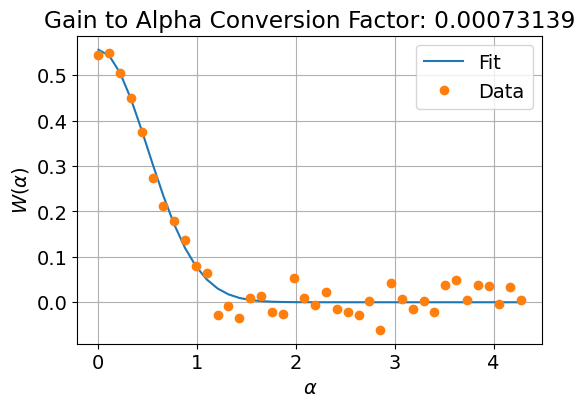

alpha = 1 requires gain of : 1367.26037159


In [16]:
if USE_QUEUE: 
    parity_gain_expt.analyze(scale=True, plot=True)

In [17]:
station.hardware_cfg.device.manipulate.gain_to_alpha[0] = parity_gain_expt.data['gain_to_alpha']
station.hardware_cfg.device.manipulate.alpha_scale[0] = parity_gain_expt.data['scale']

In [18]:
station.update_all_station_snapshots()

[CONFIG] Created new hardware_config version CFG-HW-20260421-00019
[CONFIG] Reusing existing multiphoton_config version CFG-MP-20260121-00001
[CONFIG] Reusing existing man1_storage_swap version CFG-M1-20260416-00008
[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260223-00024
Config snapshots for current station:
  hardware_config: CFG-HW-20260421-00019
  multiphoton_config: CFG-MP-20260121-00001
  man1_storage_swap: CFG-M1-20260416-00008
  floquet_storage_swap: CFG-FL-20260223-00024


{'hardware_config': 'CFG-HW-20260421-00019',
 'multiphoton_config': 'CFG-MP-20260121-00001',
 'man1_storage_swap': 'CFG-M1-20260416-00008',
 'floquet_storage_swap': 'CFG-FL-20260223-00024'}

## Cavity ramsey vs gain for Kerr

In [4]:
kerr_ramsey_defaults = AttrDict(dict(
    start=0.01,           # start delay
    step=0.02,            # step size
    expts=100,            # number of experiments
    ramsey_freq=3.7,      # Ramsey frequency
    kerr_gain=2000,
    kerr_detune=-10,
    reps=100,              # repetitions
    rounds=1,             # rounds
    qubits=[0],           # qubits
    checkEF=False,        # check EF
    f0g1_cavity=0,        # f0g1 cavity
    init_gf=False,        # initialize gf
    active_reset=False,   # active reset
    man_reset=True,       # manipulate reset
    storage_reset=True,   # storage reset
    user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
    parity_meas=True,     # parity measurement
    man_mode_no=1,
    storage_ramsey=[False, 2, True], # storage Ramsey
    man_ramsey=None,      # manipulate Ramsey
    coupler_ramsey=False, # coupler Ramsey
    custom_coupler_pulse=None, # custom coupler pulse
    echoes=[False, 0],    # echoes
    prepulse=False,       # prepulse
    postpulse=False,      # postpulse
    gate_based=False,     # gate based
    pre_sweep_pulse=None, # pre sweep pulse
    post_sweep_pulse=None,# post sweep pulse
    prep_e_first=True,
    normalize=False,
    swept_params=['displace_gain', 'kerr_detune'],
    kerr_detunes = np.linspace(-100, 100, 5).tolist(),
    displace_gains = np.arange(2000, 8001, 1000).tolist(),
    kerr_drive_type='man-qubit', # 'man-coupler', 'qubit'
    relax_delay=2500,
))

def kerr_ramsey_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    man_mode_no = expt_cfg.man_mode_no
    hw = station.hardware_cfg

    if expt_cfg.user_defined_pulse is None:
        expt_cfg.user_defined_pulse = [
            True,
            hw.device.manipulate.f_ge[man_mode_no - 1], # freq
            2000,  # will be overridden if expt_cfg.displace_gain is set! # gain
            hw.device.manipulate.displace_sigma[man_mode_no - 1], # sigma
            0, # length
            4, # proxy for ch for displacement, 4 = man
        ]
    
    # [on/off, freq, gain, sigma (mus), length, channel]
    if expt_cfg.man_ramsey is None:
        expt_cfg.man_ramsey = [False, man_mode_no - 1]
    if expt_cfg.custom_coupler_pulse is None and expt_cfg.kerr_drive_type == 'man-coupler':
        expt_cfg.custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
    if expt_cfg.pre_sweep_pulse is None:
        expt_cfg.pre_sweep_pulse = []
    if expt_cfg.post_sweep_pulse is None:
        expt_cfg.post_sweep_pulse = []

    print(expt_cfg)
    return expt_cfg

# def kerr_ramsey_postproc(station, expt):
#     pass

{'start': 0.01, 'step': 0.02, 'expts': 100, 'ramsey_freq': 4, 'kerr_gain': 0, 'kerr_detune': 0, 'reps': 50, 'rounds': 1, 'qubits': [0], 'checkEF': False, 'f0g1_cavity': 0, 'init_gf': False, 'active_reset': False, 'man_reset': True, 'storage_reset': True, 'user_defined_pulse': [True, 4997.679462583467, 2000, 0.05, 0, 4], 'parity_meas': True, 'man_mode_no': 1, 'storage_ramsey': [False, 2, True], 'man_ramsey': [False, 0], 'coupler_ramsey': False, 'custom_coupler_pulse': None, 'echoes': [False, 0], 'prepulse': False, 'postpulse': False, 'gate_based': False, 'pre_sweep_pulse': [], 'post_sweep_pulse': [], 'prep_e_first': False, 'normalize': False, 'swept_params': ['displace_gain', 'kerr_length'], 'kerr_detunes': [-100.0, -50.0, 0.0, 50.0, 100.0], 'displace_gains': [500, 1000, 1500, 2000, 2500, 3000], 'kerr_drive_type': 'man-qubit', 'relax_delay': 2500, 'kerr_lengths': [0.01, 0.0298, 0.0496, 0.06939999999999999, 0.08919999999999999, 0.10899999999999999, 0.1288, 0.1486, 0.1684, 0.1881999999999

(<Figure size 1000x900 with 4 Axes>,
 array([<Axes: title={'center': 'JOB-20260216-00136_QsimBaseExperiment.h5'}, xlabel='kerr_length', ylabel='displace_gain'>,
        <Axes: xlabel='kerr_length', ylabel='displace_gain'>], dtype=object))

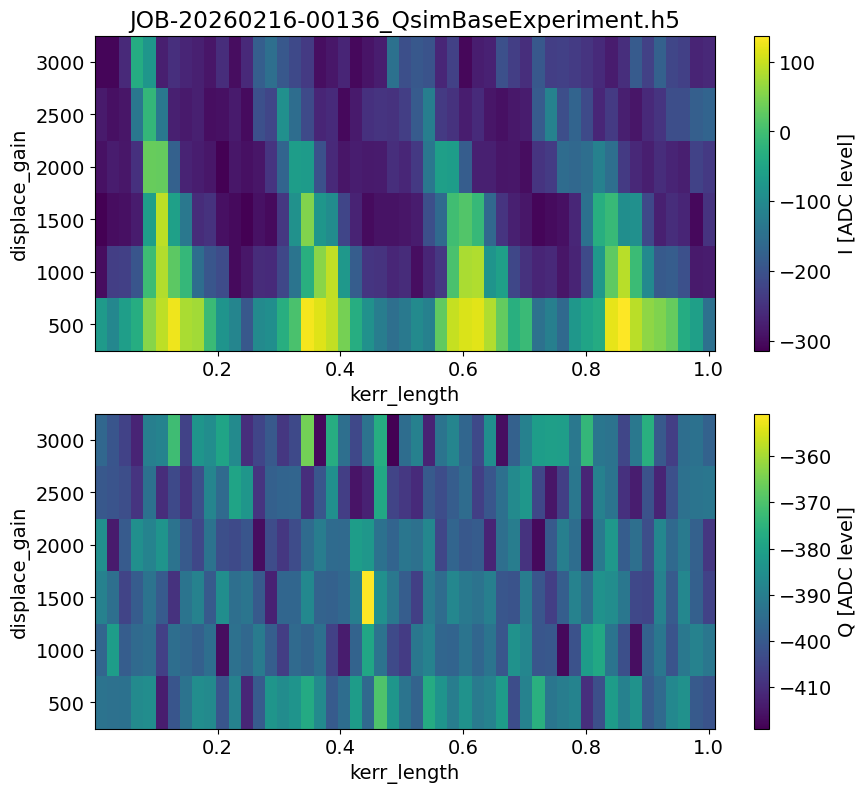

In [ ]:
kerr_ramsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.KerrCavityRamseyExperiment,
    ExptProgram=meas.qsim.kerr.KerrCavityRamseyProgram,
    default_expt_cfg=kerr_ramsey_defaults,
    preprocessor=kerr_ramsey_preproc,
    # postprocessor=kerr_ramsey_postproc,
    job_client=client,
)

kerr_lengths = np.linspace(0.010, 1, 51).tolist()
displace_gains = np.arange(500, 3001, 500).tolist()

kerr_ramsey = kerr_ramsey_runner.execute(
    ramsey_freq=4,
    kerr_gain=0, # gain for kerr pulse
    kerr_detune=0,
    reps=50,
    prep_e_first=False,
    active_reset=False,
    # man_reset=True,
    swept_params = ['displace_gain', 'kerr_length'],
    kerr_lengths = kerr_lengths,
    displace_gains = displace_gains,
    # displace_gain = 5000,
    kerr_drive_type='man-qubit', # 'man-coupler', 'qubit
)
kerr_ramsey.display()

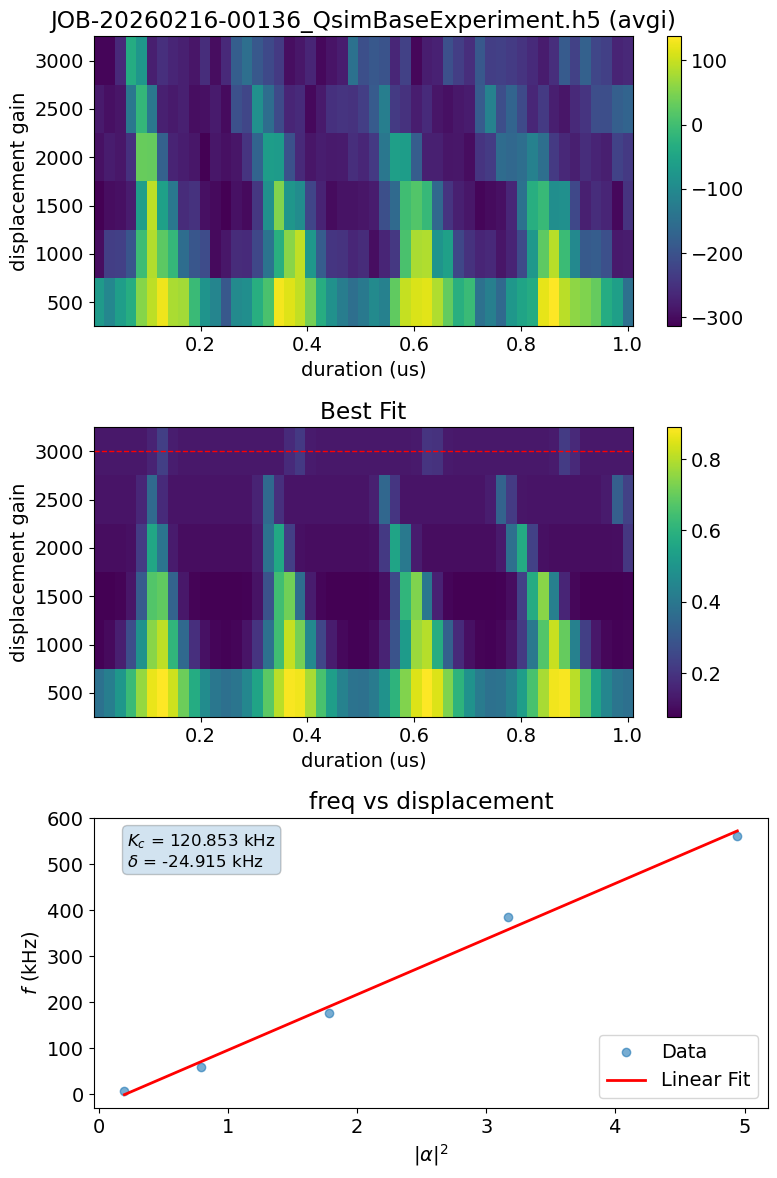

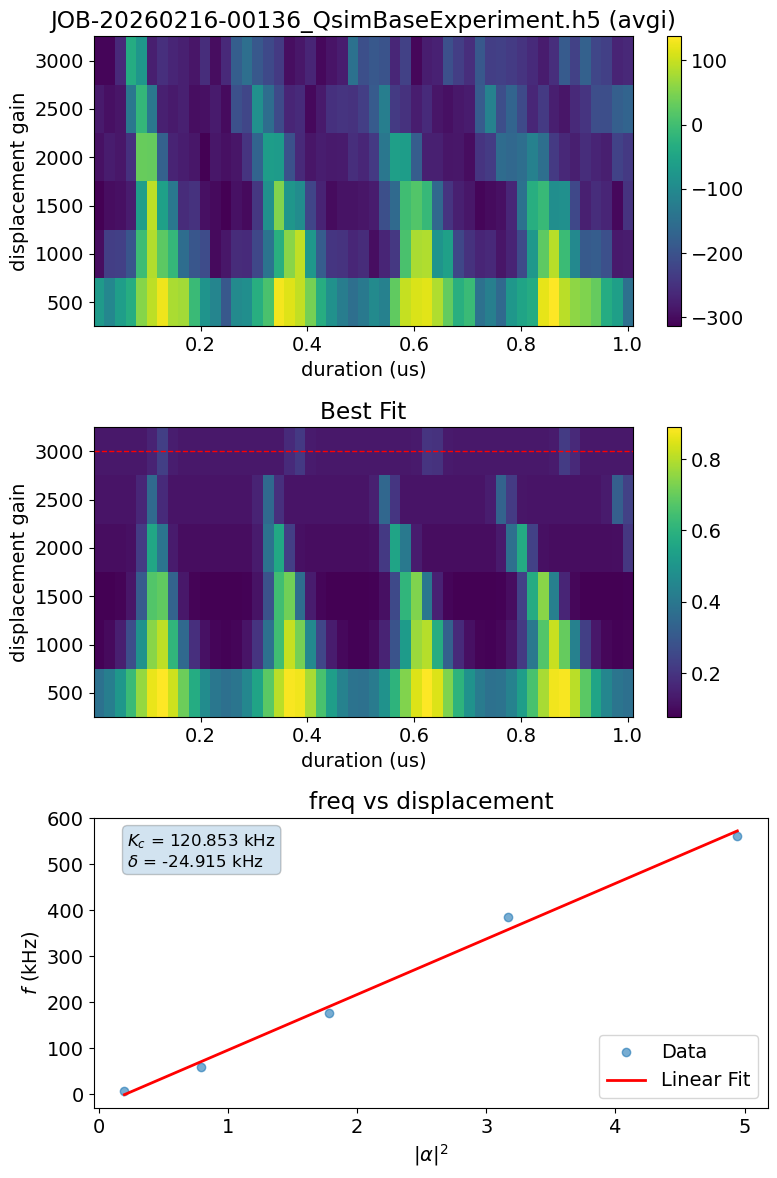

In [9]:
kerr_ramsey = meas.KerrCavityRamseyExperiment.from_h5file(r'D:\experiments\260214_qsim\data\JOB-20260216-00136_QsimBaseExperiment.h5')
kerr_ramsey.analyze()
kerr_ramsey.display()

# Qsim Wigner Tomography

## Generate Optimal Displacements 

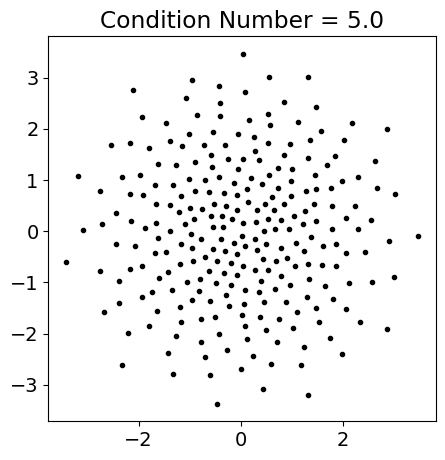

Displacements saved to D:\experiments\260214_qsim\optimized_displacements_5.npy


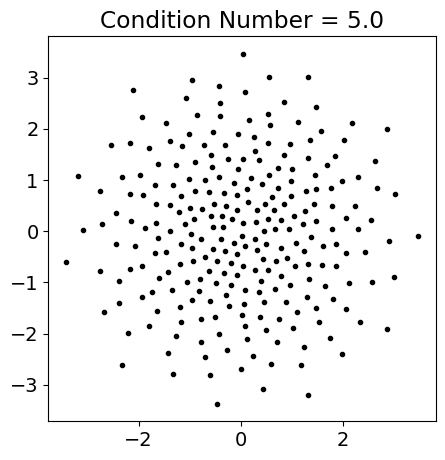

In [69]:
from fitting.wigner import OptimalDisplacementGeneration
n_photon = 16 # maximum photon number to consider
n_disps = 256 # number of displacements to use in the optimization
opt_alphas = OptimalDisplacementGeneration(FD = n_photon, n_disps=n_disps)
return_dict = opt_alphas.optimize(save_dir = station.experiment_path)


## Kerr wait

In [21]:
kerr_wait_wigner_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end

    init_fock=False,
    displacement_path= return_dict_path, # optimal displacement path
    # displacement_path= return_dict['path'], # optimal displacement path
    perform_wigner=True,
    parity_fast=False,
    pulse_correction=True,

    wait_us_times=np.linspace(0, 50, 6).tolist(),
    swept_params = ['wait_us_time'],

    # Use SweepRunner to handle the sweeping
    # dummys=[0],
    # swept_params=['dummy'],

    normalize=False,
    post_select_pre_pulse=False,
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def kerr_wait_wigner_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    assert 'init_stor' in kwargs
    if not expt_cfg.init_fock:
        assert 'init_alpha' in kwargs

    print(expt_cfg)
    return expt_cfg


# wigner_runner = SweepRunner(
#     station=station,
#     ExptClass=meas.QsimWignerBaseExperiment,
#     ExptProgram=meas.KerrWaitProgram,
#     default_expt_cfg=kerr_wait_wigner_defaults,
#     sweep_param='wait_us_time',
#     preprocessor=kerr_wait_wigner_preproc,
#     postprocessor=None,
#     job_client=client,
# )

wigner_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimWignerBaseExperiment,
    ExptProgram=meas.KerrWaitProgram,
    default_expt_cfg=kerr_wait_wigner_defaults,
    preprocessor=kerr_wait_wigner_preproc,
    postprocessor=None,
    job_client=client,
)

In [15]:
station.ds_floquet.update_len('M1-S5', 1)

In [ ]:
wigner = wigner_runner.execute(
    reps=400,
    init_fock=False,
    # init_man_fock_state='+',
    init_alpha=1.0,
    init_stor=0,
    ro_stor=0,
    relax_delay=2500, 
    parity_fast = False,

    wait_us_times=np.linspace(0, 10, 21).tolist(),

    # sweep_start=0,
    # sweep_stop=5,
    # sweep_npts=3,
    # coupler_current = 0e-3,
)

{'expts': 1, 'reps': 400, 'rounds': 1, 'qubits': [0], 'ro_stor': 0, 'init_fock': False, 'displacement_path': 'D:\\experiments\\260214_qsim\\optimized_displacements_3.npy', 'perform_wigner': True, 'parity_fast': False, 'pulse_correction': True, 'wait_us_times': [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0], 'swept_params': ['wait_us_time'], 'normalize': False, 'post_select_pre_pulse': False, 'active_reset': False, 'man_reset': False, 'storage_reset': False, 'prepulse': True, 'postpulse': True, 'init_alpha': 1.0, 'init_stor': 0, 'relax_delay': 2500}
Job submitted: JOB-20260313-00104 (queue position: 1)

[0.1s] Job JOB-20260313-00104: pending

[2.3s] Job JOB-20260313-00104: running
[WORKER] Loading QsimWignerBaseExperiment from experiments.qsim.qsim_base_wigner
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260313-00104_QsimWignerBaseExperiment.h5
[WORKER]   Program: KerrWaitProgram from experiments.qsim.kerr


In [ ]:
# test_wigner = meas.QsimWignerBaseExperiment(config_file=station.hardware_config_file, expt_params=kerr_wait_wigner_defaults)
# test_wigner.data = wigner.data
# test_wigner.outer_params = wigner.outer_params
# test_wigner.inner_params = wigner.inner_params
# test_wigner.outer_param = wigner.outer_param
# test_wigner.inner_param = wigner.inner_param
# test_wigner.pulse_correction = wigner.pulse_correction
# test_wigner.cfg = deepcopy(wigner.cfg)

# test_wigner.analyze_wigner(mode_state_num=10)

0 None
shape (201, 100)
max parity: 0.9665809755657788
max parity before scaling: 0.914826498422713
Analyzing for wait_us_time=0, dummy=None


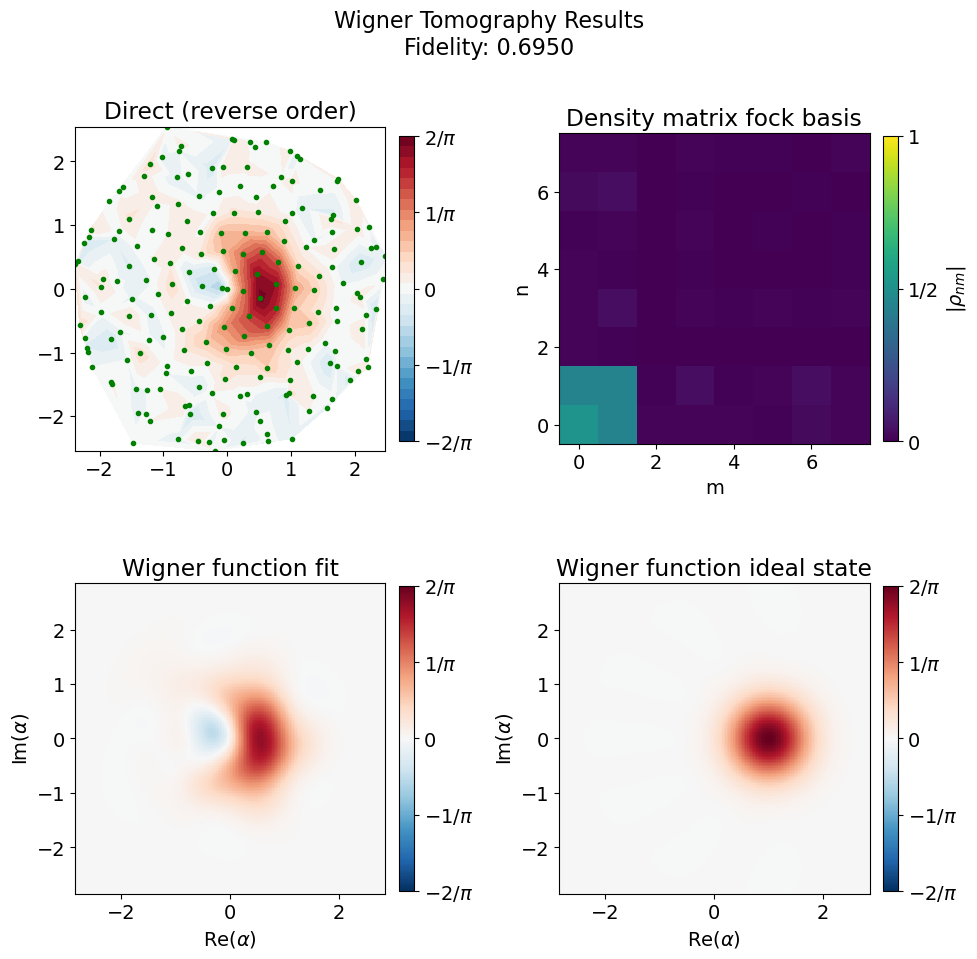

In [32]:
cutoff = 8
# ideal_state = (qt.basis(cutoff, 0)+qt.basis(cutoff, 4)).unit()
ideal_state = (qt.coherent(cutoff, 1.0)).unit()
wigner.analyze_wigner(cutoff=cutoff, debug=True)
wigner.display(rotate=True, initial_state=ideal_state, mode_state_num=cutoff, station=station, save_fig=False)


In [15]:
wigner = wigner_runner.execute(
    reps=100,
    init_fock=False,
    init_alpha=1.0,
    init_stor=0,
    ro_stor=0,
    relax_delay=2500, 
    parity_fast = False,

    wait_us_times=[5], #np.linspace(0, 100, 26).tolist(),

    # sweep_start=0,
    # sweep_stop=5,
    # sweep_npts=3,
    # coupler_current = 0e-3,
)

{'expts': 1, 'reps': 100, 'rounds': 1, 'qubits': [0], 'ro_stor': 0, 'init_fock': False, 'displacement_path': 'D:\\experiments\\260214_qsim\\optimized_displacements_3.npy', 'perform_wigner': True, 'parity_fast': False, 'pulse_correction': True, 'wait_us_times': [5], 'swept_params': ['wait_us_time'], 'normalize': False, 'post_select_pre_pulse': False, 'active_reset': False, 'man_reset': False, 'storage_reset': False, 'prepulse': True, 'postpulse': True, 'init_alpha': 1.0, 'init_stor': 0, 'relax_delay': 2500}
Job submitted: JOB-20260218-00490 (queue position: 1)

[0.1s] Job JOB-20260218-00490: pending

[2.1s] Job JOB-20260218-00490: running
[WORKER] Loading QsimWignerBaseExperiment from experiments.qsim.qsim_base_wigner
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260218-00490_QsimWignerBaseExperiment.h5
[WORKER]   Program: KerrWaitProgram from experiments.qsim.kerr
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.1mA according to hardware_cfg

In [17]:
station.update_all_station_snapshots()

[CONFIG] Reusing existing hardware_config version CFG-HW-20260218-00049
[CONFIG] Reusing existing multiphoton_config version CFG-MP-20260121-00001
[CONFIG] Reusing existing man1_storage_swap version CFG-M1-20260218-00124
[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260218-00042
Config snapshots for current station:
  hardware_config: CFG-HW-20260218-00049
  multiphoton_config: CFG-MP-20260121-00001
  man1_storage_swap: CFG-M1-20260218-00124
  floquet_storage_swap: CFG-FL-20260218-00042


{'hardware_config': 'CFG-HW-20260218-00049',
 'multiphoton_config': 'CFG-MP-20260121-00001',
 'man1_storage_swap': 'CFG-M1-20260218-00124',
 'floquet_storage_swap': 'CFG-FL-20260218-00042'}

## Kerr storage

In [ ]:
wigner = wigner_runner.execute(
    reps=100,
    init_fock=False,
    init_alpha=1.0,
    init_stor=0,
    ro_stor=0,
    relax_delay=2500, 
    parity_fast = False,

    wait_us_times=[5], #np.linspace(0, 100, 26).tolist(),

    # sweep_start=0,
    # sweep_stop=5,
    # sweep_npts=3,
    # coupler_current = 0e-3,
)

In [ ]:
wigner = wigner_runner.execute(
    reps=50,
    init_fock=False,
    init_alpha=1.0,
    init_stor=1,
    ro_stor=1,
    relax_delay=500, 
    parity_fast = False,

    wait_us_times=[5], #np.linspace(0, 50, 11).tolist(),

    # sweep_start=0,
    # sweep_stop=5,
    # sweep_npts=3,
    # coupler_current = 0e-3,
)

{'expts': 1, 'reps': 50, 'rounds': 1, 'qubits': [0], 'ro_stor': 0, 'init_fock': False, 'displacement_path': 'D:\\experiments\\260214_qsim\\optimized_displacements_4.npy', 'perform_wigner': True, 'parity_fast': False, 'pulse_correction': True, 'wait_us_times': [5], 'swept_params': ['wait_us_time'], 'normalize': False, 'post_select_pre_pulse': False, 'active_reset': False, 'man_reset': False, 'storage_reset': False, 'prepulse': True, 'postpulse': True, 'init_alpha': 1.0, 'init_stor': 0, 'relax_delay': 500}
Job submitted: JOB-20260219-00713 (queue position: 1)

[0.1s] Job JOB-20260219-00713: pending

[30.8s] Job JOB-20260219-00713: running
[WORKER] Loading QsimWignerBaseExperiment from experiments.qsim.qsim_base_wigner
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260219-00713_QsimWignerBaseExperiment.h5
[WORKER]   Program: KerrWaitProgram from experiments.qsim.kerr
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.1mA according to hardware_cfg 

## Kerr scramble

In [87]:
return_dict_path = r"D:\experiments\260214_qsim\optimized_displacements_3.npy"

In [99]:
return_dict_path = r"D:\experiments\260214_qsim\optimized_displacements_5.npy"

In [100]:
qsim_wigner_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end

    init_fock=False,
    displacement_path=return_dict_path, # optimal displacement path
    perform_wigner=True,
    parity_fast=False,
    pulse_correction=True,

    # wait_us_times=np.linspace(0, 5, 10).tolist(),
    # swept_params = ['wait_us_time'],

    # Use SweepRunner to handle the sweeping
    # dummys=[0],
    # swept_params=['dummy'],

    normalize=False,
    post_select_pre_pulse=False,
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def qsim_wigner_preproc(station, default_expt_cfg, **kwargs):
    assert 'swept_params' in kwargs
    assert len(kwargs['swept_params']) > 0

    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    assert 'init_stor' in kwargs
    if not expt_cfg.init_fock:
        assert 'init_alpha' in kwargs

    print(expt_cfg)
    return expt_cfg


# wigner_runner = SweepRunner(
#     station=station,
#     ExptClass=meas.QsimWignerBaseExperiment,
#     ExptProgram=meas.KerrWaitProgram,
#     default_expt_cfg=qsim_wigner_defaults,
#     sweep_param='wait_us_time',
#     preprocessor=qsim_wigner_preproc,
#     postprocessor=None,
#     job_client=client,
# )


In [101]:
wigner_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimWignerBaseExperiment,
    # ExptProgram=meas.KerrWaitProgram,
    ExptProgram=meas.SidebandScrambleProgram,
    default_expt_cfg=qsim_wigner_defaults,
    preprocessor=qsim_wigner_preproc,
    postprocessor=None,
    job_client=client,
)

floquet_cycles = [0] #list(range(2, 31, 2))

for ro_stor in [0,1,7]:
    for floquet_cycle in floquet_cycles:
        if floquet_cycle % 9 == 7:
            ss = ss_runner.execute(
                go_kwargs=dict(analyze=False, display=False),
                check_f=False,
                active_reset=False,
                relax_delay=2000,
            )
            
        wigner = wigner_runner.execute(
            reps=400,
            init_fock=False,
            init_alpha=2.0,
            init_stor=0,
            ro_stor=ro_stor,
            relax_delay=8000,
    
            # wait_us_times=np.linspace(0, 10, 11).tolist(),
            # swept_params=['wait_us_time'],
    
            swap_stors=[1, 7],
            update_phases=True,
            floquet_cycles=[floquet_cycle],
            swept_params=['floquet_cycle'],
    
            # sweep_start=0,
            # sweep_stop=5,
            # sweep_npts=3,
        )

{'expts': 1, 'reps': 400, 'rounds': 1, 'qubits': [0], 'ro_stor': 0, 'init_fock': False, 'displacement_path': 'D:\\experiments\\260214_qsim\\optimized_displacements_5.npy', 'perform_wigner': True, 'parity_fast': False, 'pulse_correction': True, 'normalize': False, 'post_select_pre_pulse': False, 'active_reset': False, 'man_reset': False, 'storage_reset': False, 'prepulse': True, 'postpulse': True, 'init_alpha': 2.0, 'init_stor': 0, 'relax_delay': 8000, 'swap_stors': [1, 7], 'update_phases': True, 'floquet_cycles': [0], 'swept_params': ['floquet_cycle']}
Job submitted: JOB-20260314-00067 (queue position: 1)

[0.1s] Job JOB-20260314-00067: pending

[2.1s] Job JOB-20260314-00067: running
[WORKER] Loading QsimWignerBaseExperiment from experiments.qsim.qsim_base_wigner
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260314-00067_QsimWignerBaseExperiment.h5
[WORKER]   Program: SidebandScrambleProgram from experiments.qsim.sideband_scramble
[WORKER] Running experiment...
[WOR

In [ ]:
wigner_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimWignerBaseExperiment,
    # ExptProgram=meas.KerrWaitProgram,
    ExptProgram=meas.SidebandScrambleProgram,
    default_expt_cfg=qsim_wigner_defaults,
    preprocessor=qsim_wigner_preproc,
    postprocessor=None,
    job_client=client,
)

floquet_cycles = list(range(0, 41, 4))
print(floquet_cycles)

for ro_stor in [0,1,7]:
    for floquet_cycle in floquet_cycles:
        wigner = wigner_runner.execute(
            reps=100,
            init_fock=False,
            init_alpha=1.0,
            init_stor=0,
            ro_stor=ro_stor,
            relax_delay=8000,
    
            # wait_us_times=np.linspace(0, 10, 11).tolist(),
            # swept_params=['wait_us_time'],
    
            swap_stors=[1, 7],
            update_phases=True,
            detunings=[0.2, 0.2],
            floquet_cycles=[floquet_cycle],
            swept_params=['floquet_cycle'],
    
            # sweep_start=0,
            # sweep_stop=5,
            # sweep_npts=3,
        )

40 None
shape (201, 100)
max parity: 0.8094557204122599
max parity before scaling: 0.7758439924512474
Analyzing for floquet_cycle=40, dummy=None


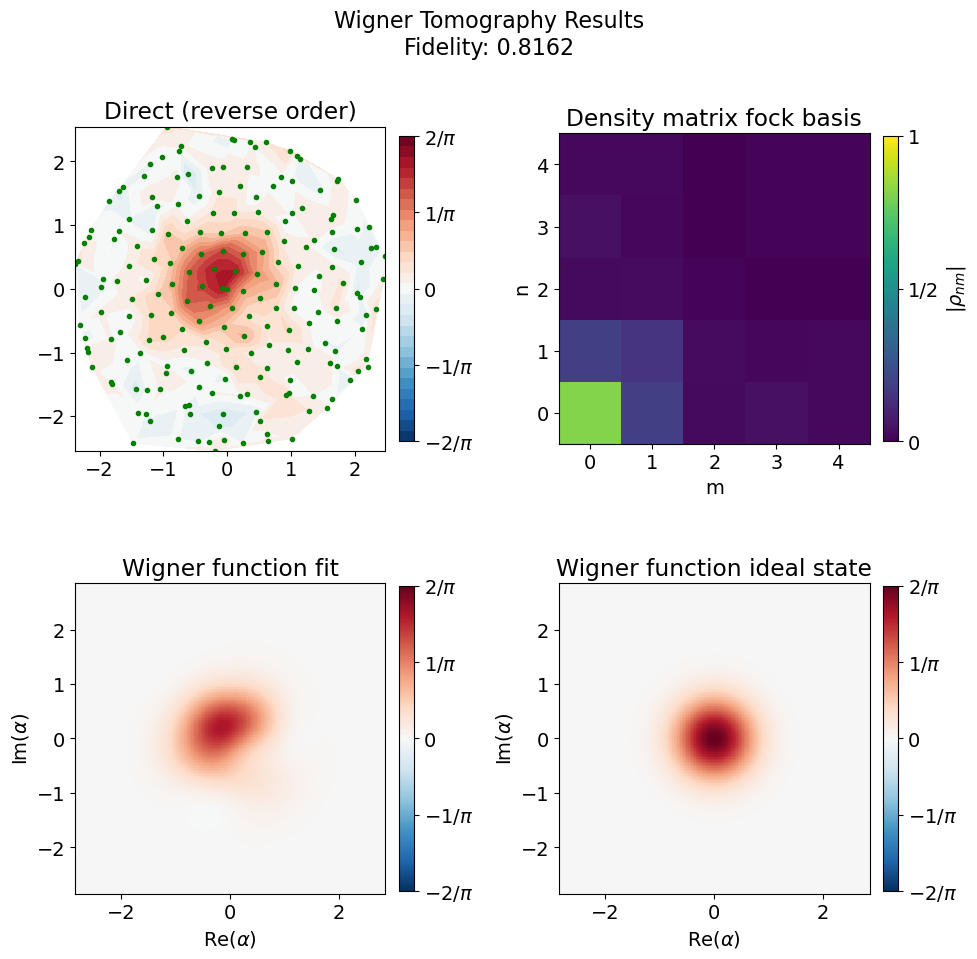

In [19]:
wigner.analyze_wigner()
wigner.display()

In [23]:
from fitting.fitting import wigner_purity_calculation

In [24]:
wigner_purity_calculation(wigner, cutoff=8)

40 None
shape (201, 100)
max parity: 0.8094557204122599
max parity before scaling: 0.7758439924512474
Analyzing for floquet_cycle=40, dummy=None


array([[0.72935112+1.03541307e-16j]])

## Cooling

In [19]:
return_dict_path = r"D:\experiments\260214_qsim\optimized_displacements_5.npy"

In [22]:
qsim_wigner_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end

    init_fock=False,
    displacement_path=return_dict_path, # optimal displacement path
    perform_wigner=True,
    parity_fast=False,
    pulse_correction=True,

    # wait_us_times=np.linspace(0, 5, 10).tolist(),
    # swept_params = ['wait_us_time'],

    # Use SweepRunner to handle the sweeping
    # dummys=[0],
    # swept_params=['dummy'],

    normalize=False,
    post_select_pre_pulse=False,
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def qsim_wigner_preproc(station, default_expt_cfg, **kwargs):
    assert 'swept_params' in kwargs
    assert len(kwargs['swept_params']) > 0

    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    assert 'init_stor' in kwargs
    if not expt_cfg.init_fock:
        assert 'init_alpha' in kwargs

    print(expt_cfg)
    return expt_cfg


# wigner_runner = SweepRunner(
#     station=station,
#     ExptClass=meas.QsimWignerBaseExperiment,
#     ExptProgram=meas.KerrWaitProgram,
#     default_expt_cfg=qsim_wigner_defaults,
#     sweep_param='wait_us_time',
#     preprocessor=qsim_wigner_preproc,
#     postprocessor=None,
#     job_client=client,
# )


In [25]:
wigner_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimWignerBaseExperiment,
    ExptProgram=meas.CoolingSpectroscopyProgram,
    default_expt_cfg=qsim_wigner_defaults,
    preprocessor=qsim_wigner_preproc,
    postprocessor=None,
    job_client=client,
)

wigner = wigner_runner.execute(
    reps=400,
    prepulse=False,
    init_stor=0,
    init_alpha=0,
    ro_stor=0,
    relax_delay=8000,
    # wait_us_times=np.linspace(0, 10, 11).tolist(),
    swept_params=['cooling_length'],

    cooling_freq=7147.12,
    cooling_gain=30000,
    cooling_lengths=[4.2],

    # sweep_start=0,
    # sweep_stop=5,
    # sweep_npts=3,
)

{'expts': 1, 'reps': 50, 'rounds': 1, 'qubits': [0], 'ro_stor': 0, 'init_fock': False, 'displacement_path': 'D:\\experiments\\260214_qsim\\optimized_displacements_5.npy', 'perform_wigner': True, 'parity_fast': False, 'pulse_correction': True, 'normalize': False, 'post_select_pre_pulse': False, 'active_reset': False, 'man_reset': False, 'storage_reset': False, 'prepulse': False, 'postpulse': True, 'init_stor': 0, 'init_alpha': 0, 'relax_delay': 5000, 'swept_params': ['cooling_length'], 'cooling_freq': 7147.12, 'cooling_gain': 30000, 'cooling_lengths': [10]}
Job submitted: JOB-20260421-00405 (queue position: 1)

[0.1s] Job JOB-20260421-00405: pending

[2.1s] Job JOB-20260421-00405: running
[WORKER] Loading QsimWignerBaseExperiment from experiments.qsim.qsim_base_wigner
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260421-00405_QsimWignerBaseExperiment.h5
[WORKER]   Program: CoolingSpectroscopyProgram from experiments.qsim.cooling
[WORKER] Running experiment...
[WORKER

10 None
shape (257, 50)
max parity: 0.3264507944708721
max parity before scaling: 0.28515577007459425
Analyzing for cooling_length=10, dummy=None


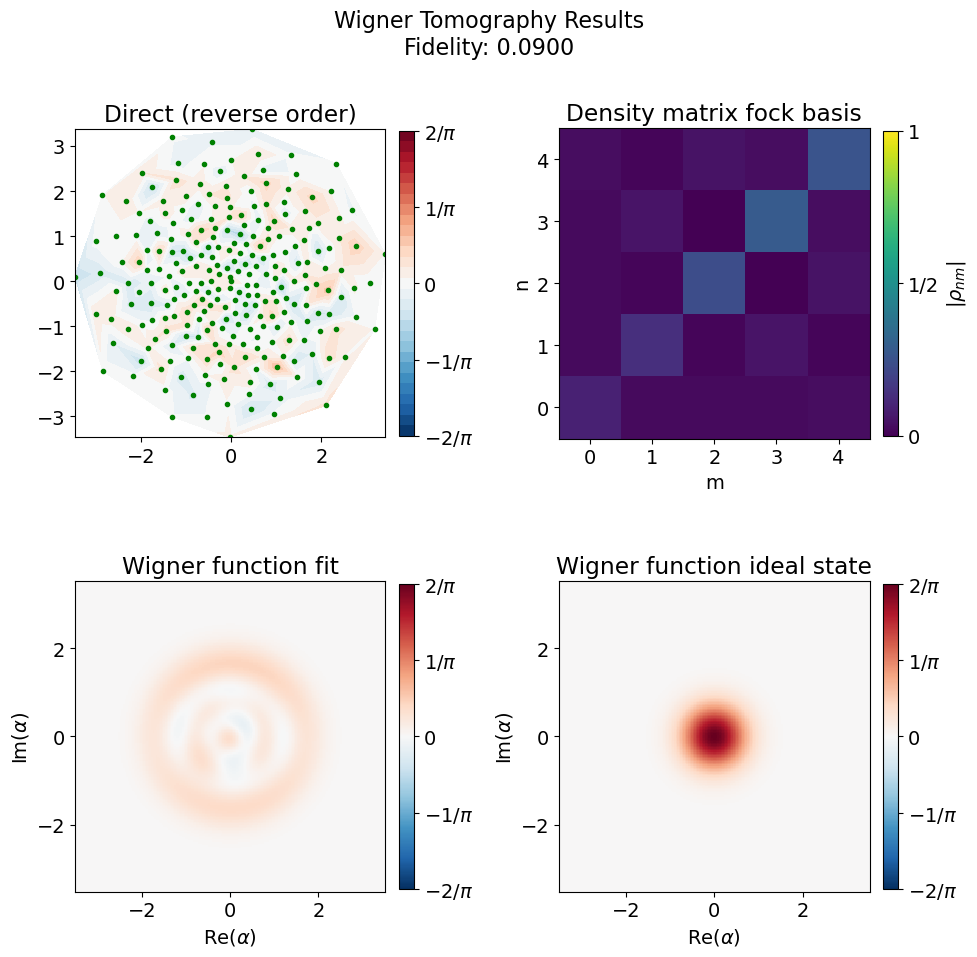

In [26]:
wigner.analyze_wigner()
wigner.display()